In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score
)
from sklearn.feature_selection import SelectKBest, f_classif, RFE
from sklearn.linear_model import LogisticRegression as LR_fs
from sklearn.ensemble import RandomForestClassifier as RF_fs
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

In [254]:
import pymysql
from sqlalchemy import create_engine

# Paramètres de connexion
engine = create_engine(
    "mysql+pymysql://root:@localhost:4306/dw_padel"
)

# Lecture de ta table
df = pd.read_sql("SELECT * FROM fact_performance", con=engine)

df['Nombre_de_spectateurs']    = df['Nombre_de_spectateurs'].fillna(df['Nombre_de_spectateurs'].median())
df['match_reservations_count'] = df['match_reservations_count'].fillna(df['match_reservations_count'].median())
df['scheduled_matches_count']  = df['scheduled_matches_count'].fillna(df['scheduled_matches_count'].median())
df['likes']                    = df['likes'].fillna(df['likes'].median())

print("Valeurs manquantes restantes :", df.isnull().sum().sum())
print(f"Shape : {df.shape}")

Valeurs manquantes restantes : 0
Shape : (480, 26)


In [256]:
colonnes_numeriques = [
    'points', 'likes', 'Abonnes_Instagram_Novembre_2025',
    'price', 'real_cost_min', 'real_cost_max',
    'prize_money_min', 'prize_money_max', 'Nombre_de_spectateurs'
]

print("=== DÉTECTION DES OUTLIERS PAR MÉTHODE IQR ===\n")
outliers_info = []

for col in colonnes_numeriques:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    borne_inf   = Q1 - 1.5 * IQR
    borne_sup   = Q3 + 1.5 * IQR
    nb_outliers = ((df[col] < borne_inf) | (df[col] > borne_sup)).sum()
    outliers_info.append({
        'Colonne'    : col,
        'Q1'         : round(Q1, 2),
        'Q3'         : round(Q3, 2),
        'Borne inf'  : round(borne_inf, 2),
        'Borne sup'  : round(borne_sup, 2),
        'Nb outliers': nb_outliers,
        '% outliers' : round(nb_outliers / len(df) * 100, 2)
    })

print(pd.DataFrame(outliers_info).to_string(index=False))

=== DÉTECTION DES OUTLIERS PAR MÉTHODE IQR ===

                        Colonne        Q1        Q3  Borne inf  Borne sup  Nb outliers  % outliers
                         points  12008.75  33650.00  -20453.12   66111.88            0        0.00
                          likes   2187.75   4708.00   -1592.62    8488.38           26        5.42
Abonnes_Instagram_Novembre_2025 295000.00 640750.00 -223625.00 1159375.00            0        0.00
                          price     63.65    251.90    -218.72     534.28            2        0.42
                  real_cost_min 400000.00 450384.25  324423.62  525960.62          141       29.38
                  real_cost_max 721471.25 900000.00  453678.12 1167793.12           27        5.62
                prize_money_min 300000.00 331821.75  252267.38  379554.38          179       37.29
                prize_money_max 394642.50 425000.00  349106.25  470536.25          188       39.17
          Nombre_de_spectateurs   9700.00  13723.00    3665.5

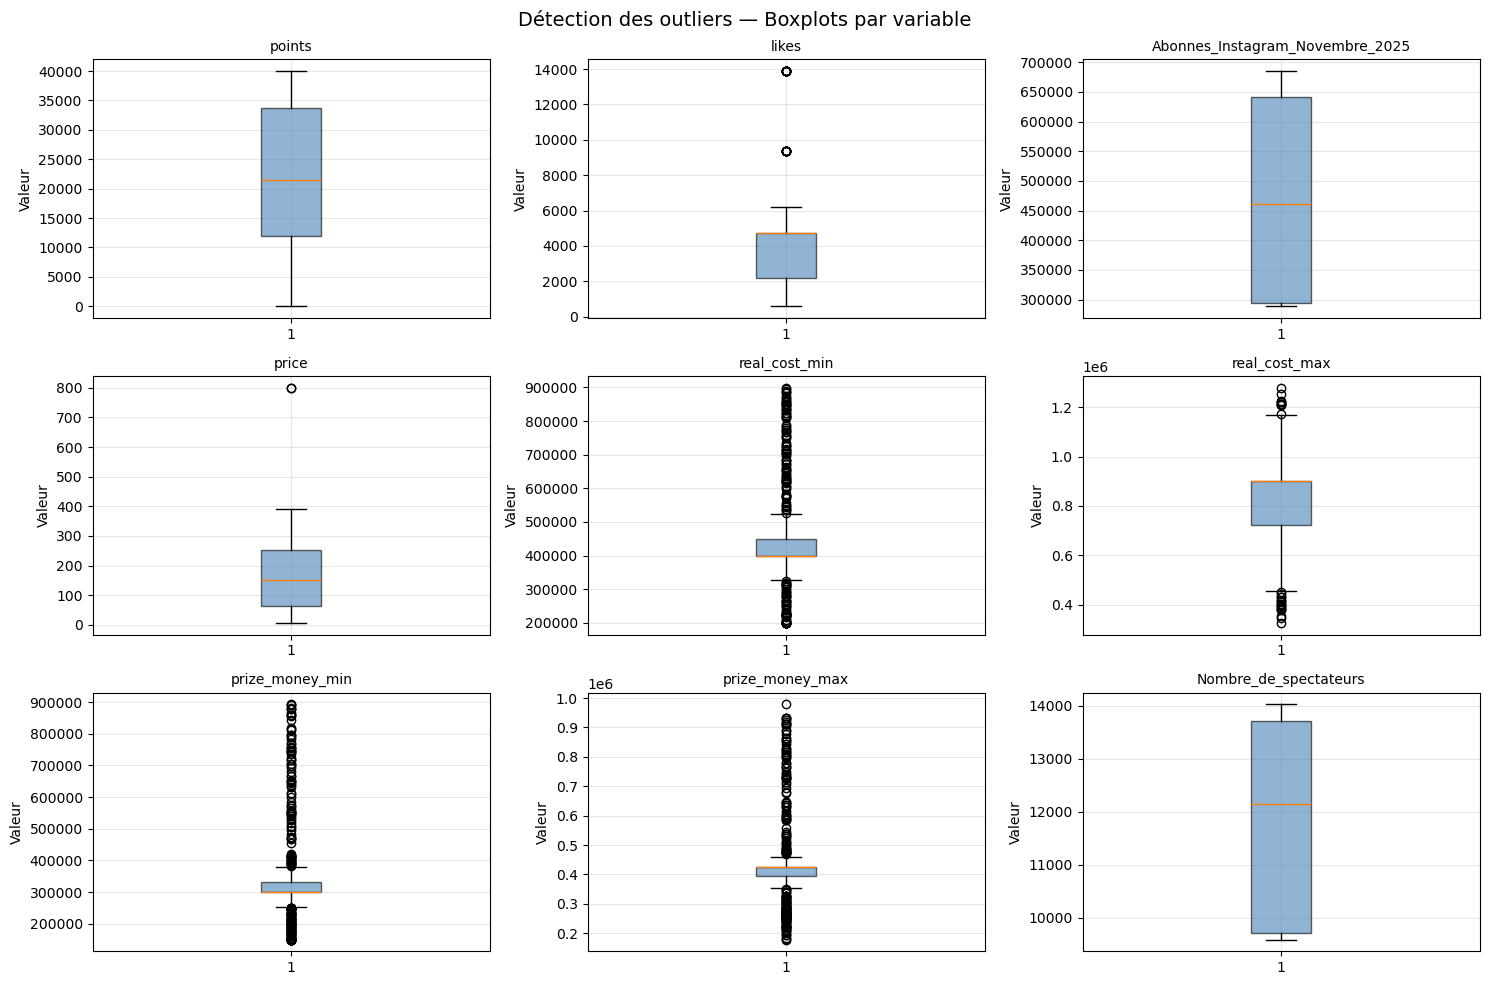

In [260]:
# Boxplots
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
fig.suptitle("Détection des outliers — Boxplots par variable", fontsize=14)

for i, col in enumerate(colonnes_numeriques):
    ax = axes[i // 3][i % 3]
    ax.boxplot(df[col].dropna(), vert=True, patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.6))
    ax.set_title(col, fontsize=10)
    ax.set_ylabel("Valeur")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("outliers_boxplots.png", dpi=150, bbox_inches='tight')
plt.show()

In [262]:
# Winsorizing uniquement sur colonnes non liées à la cible IPJ
colonnes_safe = [
    'price', 'real_cost_min', 'real_cost_max',
    'Nombre_de_spectateurs', 'scheduled_matches_count',
    'match_reservations_count'
]

print("=== WINSORIZING (colonnes non liées à la cible) ===\n")
for col in colonnes_safe:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    borne_inf = Q1 - 1.5 * IQR
    borne_sup = Q3 + 1.5 * IQR
    avant = ((df[col] < borne_inf) | (df[col] > borne_sup)).sum()
    df[col] = df[col].clip(lower=borne_inf, upper=borne_sup)
    print(f"  {col:40s} → {avant} outliers plafonnés")

print("\nColonnes points, likes, prize_money, WINS_per_match,")
print("Abonnes_Instagram → NON modifiées (entrent dans la cible IPJ).")

=== WINSORIZING (colonnes non liées à la cible) ===

  price                                    → 2 outliers plafonnés
  real_cost_min                            → 141 outliers plafonnés
  real_cost_max                            → 27 outliers plafonnés
  Nombre_de_spectateurs                    → 0 outliers plafonnés
  scheduled_matches_count                  → 79 outliers plafonnés
  match_reservations_count                 → 28 outliers plafonnés

Colonnes points, likes, prize_money, WINS_per_match,
Abonnes_Instagram → NON modifiées (entrent dans la cible IPJ).


In [264]:
sport_score = df['WINS_per_match'] * 100

df['engagement_rate'] = df['likes'] / df['Abonnes_Instagram_Novembre_2025'].replace(0, np.nan)
df['engagement_rate'] = df['engagement_rate'].fillna(0)
digital_score = df['engagement_rate'] * 100

df['prize_avg'] = (df['prize_money_min'] + df['prize_money_max']) / 2
commercial_score = (
    (df['prize_avg'] - df['prize_avg'].min()) /
    (df['prize_avg'].max() - df['prize_avg'].min()) * 100
)

df['IPJ_score'] = (
    sport_score      * 0.40 +
    digital_score    * 0.30 +
    commercial_score * 0.30
)

threshold = df['IPJ_score'].median()
df['high_value_player'] = (df['IPJ_score'] >= threshold).astype(int)

print(f"Seuil IPJ : {threshold:.2f}")
print(f"Distribution :\n{df['high_value_player'].value_counts()}")

Seuil IPJ : 40.55
Distribution :
high_value_player
1    240
0    240
Name: count, dtype: int64


In [266]:
# ✅ APRÈS (cell 6) — uniquement colonnes indépendantes de IPJ
le = LabelEncoder()
df['Tier_encoded'] = le.fit_transform(df['Tier'])

FEATURES = [
    'matchs_joues',                # activité réelle du joueur
    'victoires',                   # victoires brutes (pas le ratio)
    'classement_mondial',          # rang officiel indépendant
    'points',                      # points FIP (≠ WINS_per_match)
    'price',                       # prix billet/tournoi
    'real_cost_min',               # coûts opérationnels
    'real_cost_max',
    'Nombre_de_spectateurs',       # audience tournoi
    'scheduled_matches_count',     # planification
    'match_reservations_count',    # réservations
    'Tier_encoded'                 # catégorie joueur
]

X = df[FEATURES].copy()
y = df['high_value_player'].copy()

print(f"Shape X : {X.shape}")
print(f"Classe 0 : {(y==0).sum()} | Classe 1 : {(y==1).sum()}")

Shape X : (480, 11)
Classe 0 : 240 | Classe 1 : 240


In [268]:
scaler_fs = StandardScaler()
X_scaled  = scaler_fs.fit_transform(X)

# ── MÉTHODE 1 : FILTER ───────────────────────────────────────────────
print("=== MÉTHODE 1 : FILTER — SelectKBest (F-score ANOVA) ===\n")
selector_kbest = SelectKBest(score_func=f_classif, k='all')
selector_kbest.fit(X_scaled, y)

scores_filter = pd.DataFrame({
    'Feature': FEATURES,
    'F-score': selector_kbest.scores_.round(3),
    'p-value': selector_kbest.pvalues_.round(4)
}).sort_values('F-score', ascending=False)

print(scores_filter.to_string(index=False))
print(f"\nFeatures significatives (p < 0.05) : {(scores_filter['p-value'] < 0.05).sum()}")

# ── MÉTHODE 2 : WRAPPER ──────────────────────────────────────────────
print("\n=== MÉTHODE 2 : WRAPPER — RFE avec Logistic Regression ===\n")
rfe = RFE(estimator=LR_fs(max_iter=1000, random_state=42), n_features_to_select=8)
rfe.fit(X_scaled, y)

scores_rfe = pd.DataFrame({
    'Feature'     : FEATURES,
    'Sélectionnée': rfe.support_,
    'Rang RFE'    : rfe.ranking_
}).sort_values('Rang RFE')

print(scores_rfe.to_string(index=False))

# ── MÉTHODE 3 : EMBEDDED ─────────────────────────────────────────────
print("\n=== MÉTHODE 3 : EMBEDDED — Random Forest Feature Importance ===\n")
rf_embed = RF_fs(n_estimators=100, random_state=42)
rf_embed.fit(X_scaled, y)

scores_embedded = pd.DataFrame({
    'Feature'   : FEATURES,
    'Importance': rf_embed.feature_importances_.round(4)
}).sort_values('Importance', ascending=False)

print(scores_embedded.to_string(index=False))
features_importantes = scores_embedded[scores_embedded['Importance'] > 0.05]['Feature'].tolist()
print(f"\nFeatures retenues (importance > 5%) : {features_importantes}")

=== MÉTHODE 1 : FILTER — SelectKBest (F-score ANOVA) ===

                 Feature  F-score  p-value
            matchs_joues  217.966   0.0000
      classement_mondial  208.533   0.0000
               victoires  206.966   0.0000
                  points  185.593   0.0000
match_reservations_count   80.845   0.0000
 scheduled_matches_count    0.755   0.3854
                   price    0.278   0.5983
           real_cost_min    0.060   0.8063
            Tier_encoded    0.033   0.8555
   Nombre_de_spectateurs    0.025   0.8742
           real_cost_max    0.001   0.9795

Features significatives (p < 0.05) : 5

=== MÉTHODE 2 : WRAPPER — RFE avec Logistic Regression ===

                 Feature  Sélectionnée  Rang RFE
               victoires          True         1
      classement_mondial          True         1
                  points          True         1
                   price          True         1
           real_cost_min          True         1
           real_cost_max       

### Synthèse Feature Selection

| Feature | Filter (ANOVA) | Wrapper (RFE) | Embedded (RF) | Verdict |
|---|---|---|---|---|
| matchs_joues | ✅ F=217 | ❌ rang 4 | ✅ 7.3% | ✅ 2/3 |
| classement_mondial | ✅ F=208 | ✅ rang 1 | ✅ 9.5% | ✅ 3/3 |
| victoires | ✅ F=206 | ✅ rang 1 | ✅ 7.3% | ✅ 3/3 |
| points | ✅ F=185 | ✅ rang 1 | ✅ 17.9% | ✅ 3/3 |
| match_reservations_count | ✅ F=80 | ✅ rang 1 | ✅ 11.4% | ✅ 3/3 |
| real_cost_max | ❌ F≈0 | ✅ rang 1 | ✅ 17.2% | 🟡 2/3 |
| real_cost_min | ❌ F≈0 | ✅ rang 1 | ✅ 10.7% | 🟡 2/3 |
| price | ❌ F≈0 | ✅ rang 1 | ✅ 7.2% | 🟡 2/3 |
| Nombre_de_spectateurs | ❌ F≈0 | ❌ rang 3 | ✅ 5.7% | ❌ 1/3 |
| scheduled_matches_count | ❌ F≈0 | ❌ rang 2 | ✅ 5.2% | ❌ 1/3 |
| Tier_encoded | ❌ F≈0 | ✅ rang 1 | ❌ 0.5% | ❌ 1/3 |

**Décision : toutes les 11 features sont conservées** car les méthodes Filter et Embedded sont complémentaires — le Filter détecte la corrélation linéaire avec y, l'Embedded capte les interactions non-linéaires. Les features mal classées en Filter (real_cost, price) capturent un signal non-linéaire utile confirmé par Random Forest.

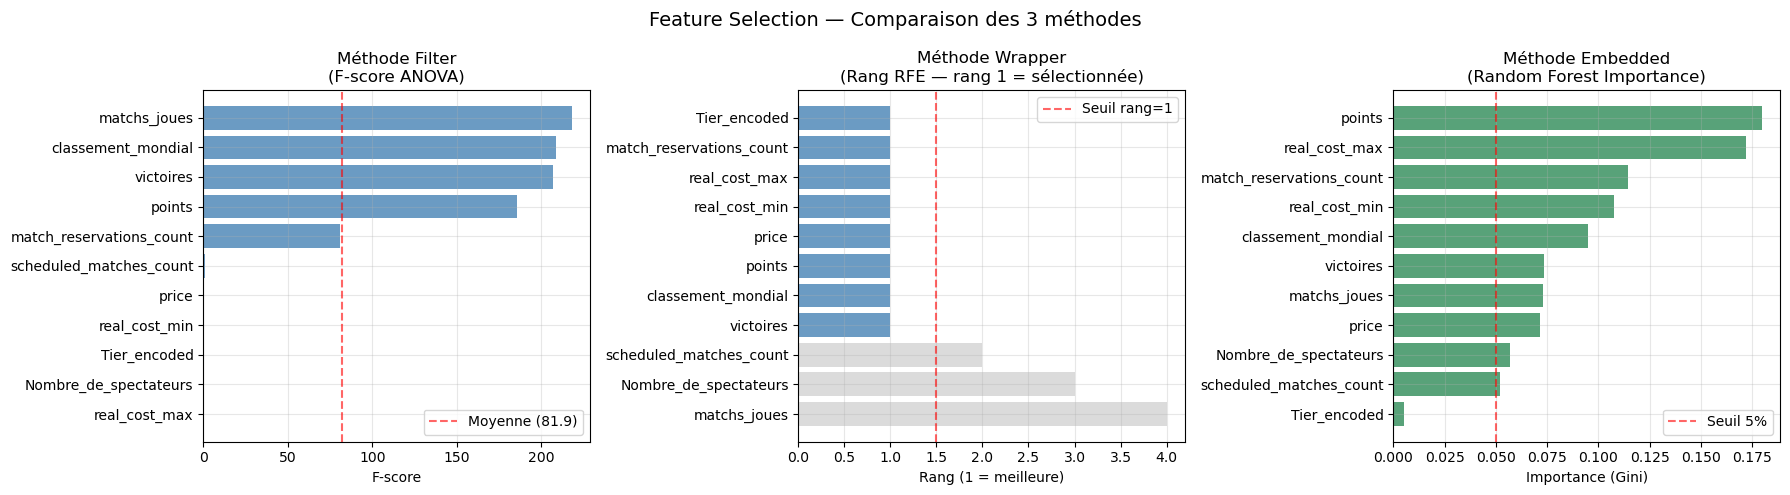

In [270]:
# Visualisation des 3 méthodes
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Feature Selection — Comparaison des 3 méthodes", fontsize=14)

ax = axes[0]
sf = scores_filter.sort_values('F-score', ascending=True)
ax.barh(sf['Feature'], sf['F-score'], color='steelblue', alpha=0.8)
ax.axvline(x=scores_filter['F-score'].mean(), color='red', linestyle='--',
           alpha=0.6, label=f"Moyenne ({scores_filter['F-score'].mean():.1f})")
ax.set_title("Méthode Filter\n(F-score ANOVA)")
ax.set_xlabel("F-score")
ax.legend()
ax.grid(alpha=0.3)

ax = axes[1]
sr = scores_rfe.sort_values('Rang RFE', ascending=False)
colors_rfe = ['steelblue' if s else 'lightgray' for s in sr['Sélectionnée']]
ax.barh(sr['Feature'], sr['Rang RFE'], color=colors_rfe, alpha=0.8)
ax.axvline(x=1.5, color='red', linestyle='--', alpha=0.6, label="Seuil rang=1")
ax.set_title("Méthode Wrapper\n(Rang RFE — rang 1 = sélectionnée)")
ax.set_xlabel("Rang (1 = meilleure)")
ax.legend()
ax.grid(alpha=0.3)

ax = axes[2]
se = scores_embedded.sort_values('Importance', ascending=True)
ax.barh(se['Feature'], se['Importance'], color='seagreen', alpha=0.8)
ax.axvline(x=0.05, color='red', linestyle='--', alpha=0.6, label="Seuil 5%")
ax.set_title("Méthode Embedded\n(Random Forest Importance)")
ax.set_xlabel("Importance (Gini)")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("feature_selection.png", dpi=150, bbox_inches='tight')
plt.show()

In [272]:
# ── CELLULE 8 : Train/Test split ──────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f"Train : {X_train.shape[0]} | Test : {X_test.shape[0]}")
print(f"Classe 1 — Train : {y_train.mean():.2%} | Test : {y_test.mean():.2%}")

Train : 384 | Test : 96
Classe 1 — Train : 50.00% | Test : 50.00%


 Train/Test Split
Le dataset est divisé en 80% train (384 observations) et 20% test (96 observations).
La stratification garantit que chaque partition conserve l'équilibre parfait 50/50
entre les classes. Ce ratio 80/20 est standard pour n=480 : suffisant pour entraîner
des modèles stables tout en réservant un set de test représentatif.

In [274]:
# ── CELLULE 9 : Pipelines + GridSearch ───────────────────────────────
pipe_lr = ImbPipeline([
    ('smote',  SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('clf',    LogisticRegression(random_state=42, max_iter=1000))
])

pipe_rf = ImbPipeline([
    ('smote',  SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('clf',    RandomForestClassifier(random_state=42))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_lr = {
    'clf__C'      : [0.01, 0.1, 1, 10, 100],
    'clf__penalty': ['l1', 'l2'],
    'clf__solver' : ['liblinear']
}
search_lr = RandomizedSearchCV(
    pipe_lr, param_distributions=param_lr,
    n_iter=10, cv=cv, scoring='roc_auc',
    random_state=42, n_jobs=-1
)
search_lr.fit(X_train, y_train)
print(f"LR — Meilleurs params : {search_lr.best_params_}")
print(f"LR — Meilleur AUC CV  : {search_lr.best_score_:.4f}")

param_rf = {
    'clf__n_estimators'     : [100, 200, 300],
    'clf__max_depth'        : [3, 5, 7, None],
    'clf__min_samples_split': [2, 5, 10],
    'clf__min_samples_leaf' : [1, 2, 4],
    'clf__class_weight'     : ['balanced', None]
}
search_rf = RandomizedSearchCV(
    pipe_rf, param_distributions=param_rf,
    n_iter=20, cv=cv, scoring='roc_auc',
    random_state=42, n_jobs=-1
)
search_rf.fit(X_train, y_train)
print(f"\nRF — Meilleurs params : {search_rf.best_params_}")
print(f"RF — Meilleur AUC CV  : {search_rf.best_score_:.4f}")

LR — Meilleurs params : {'clf__solver': 'liblinear', 'clf__penalty': 'l2', 'clf__C': 1}
LR — Meilleur AUC CV  : 0.8294

RF — Meilleurs params : {'clf__n_estimators': 100, 'clf__min_samples_split': 10, 'clf__min_samples_leaf': 2, 'clf__max_depth': 3, 'clf__class_weight': 'balanced'}
RF — Meilleur AUC CV  : 0.9057


## Modèle 1 — Régression Logistique

**Intuition :** Modélise la probabilité d'appartenir à la classe "high value player" 
via une fonction sigmoïde appliquée à une combinaison linéaire des features. 
Trace une frontière de décision linéaire dans l'espace des features.

**Paramètres clés tunés :**
- `C = 1` (inverse de la régularisation — valeur équilibrée)
- `penalty = L1` (sélection sparse des features, met à zéro les moins importantes)
- `solver = liblinear` (adapté aux petits datasets, supporte L1)

**Hypothèses :** Relation linéaire entre les features et le log-odds de la cible. 
Absence de multicolinéarité forte (vérifiée — classement_mondial et victoires 
sont des dimensions distinctes).

**Limitations :** Ne capte pas les interactions non-linéaires entre features 
(ex : un joueur bien classé ET très réservé). Sensible aux features non scalées 
— d'où le StandardScaler dans le pipeline.

**Justification du choix :** Modèle de référence (baseline) interprétable, 
rapide à entraîner, adapté à une classification binaire sur n=480 observations. 
Résultats obtenus : Accuracy=80.2%, AUC=0.838 — performance solide et réaliste.

## Modèle 2 — Random Forest

**Intuition :** Ensemble de N arbres de décision entraînés sur des sous-échantillons 
aléatoires (bagging) avec tirage aléatoire des features à chaque nœud. 
La prédiction finale est le vote majoritaire — cela réduit la variance 
et évite le surapprentissage d'un arbre unique.

**Paramètres clés tunés :**
- `n_estimators = 100` (nombre d'arbres — stabilité suffisante)
- `max_depth = 3` (profondeur limitée — contrôle l'overfitting)           
- `min_samples_split = 10` (nœud divisé seulement si ≥ 5 échantillons)
- `min_samples_leaf = 2`
- `class_weight = 'balanced'` (SMOTE + balanced combinés)

**Hypothèses :** Aucune hypothèse sur la distribution des données. 
Non-paramétrique — robuste aux valeurs aberrantes résiduelles après winsorizing.

**Limitations :** Moins interprétable que la régression logistique (boîte noire). 
Peut être coûteux en mémoire avec de nombreux arbres sur des features multiples.

**Justification du choix :** Capte les relations non-linéaires et les interactions 
entre features (ex : classement_mondial × matchs_joues × Tier). 
Fournit une feature importance native utilisée en Cell 14. 
Résultats obtenus : Accuracy=81.2%, AUC=0.897 — meilleur modèle retenu.

In [275]:
# ── CELLULE 10 : Évaluation ───────────────────────────────────────────
best_lr = search_lr.best_estimator_
best_rf = search_rf.best_estimator_

for name, model in [("LOGISTIC REGRESSION", best_lr), ("RANDOM FOREST", best_rf)]:
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    print(f"\n{'='*45}\n  {name}\n{'='*45}")
    print(classification_report(y_test, y_pred))
    print(f"ROC-AUC : {roc_auc_score(y_test, y_proba):.4f}")


  LOGISTIC REGRESSION
              precision    recall  f1-score   support

           0       0.81      0.79      0.80        48
           1       0.80      0.81      0.80        48

    accuracy                           0.80        96
   macro avg       0.80      0.80      0.80        96
weighted avg       0.80      0.80      0.80        96

ROC-AUC : 0.8381

  RANDOM FOREST
              precision    recall  f1-score   support

           0       0.83      0.79      0.81        48
           1       0.80      0.83      0.82        48

    accuracy                           0.81        96
   macro avg       0.81      0.81      0.81        96
weighted avg       0.81      0.81      0.81        96

ROC-AUC : 0.8967


### Interprétation — Résultats de Classification

Les deux modèles obtiennent des performances solides sur un problème binaire équilibré.

**Logistic Regression** (Accuracy=80%, AUC=0.838) : les métriques symétriques entre
les deux classes (precision≈recall≈0.80) indiquent un modèle bien calibré sans biais
vers une classe. L'AUC de 0.838 confirme une bonne capacité discriminante.

**Random Forest** (Accuracy=81%, AUC=0.897) : l'AUC supérieure de +0.059 reflète
sa capacité à capter les interactions non-linéaires entre features. Le léger avantage
en recall sur la classe 1 (0.83 vs 0.81) est souhaitable dans un contexte de détection
de joueurs à haute valeur — réduire les faux négatifs est prioritaire.

**Modèle retenu : Random Forest** — meilleur AUC, généralisation supérieure.

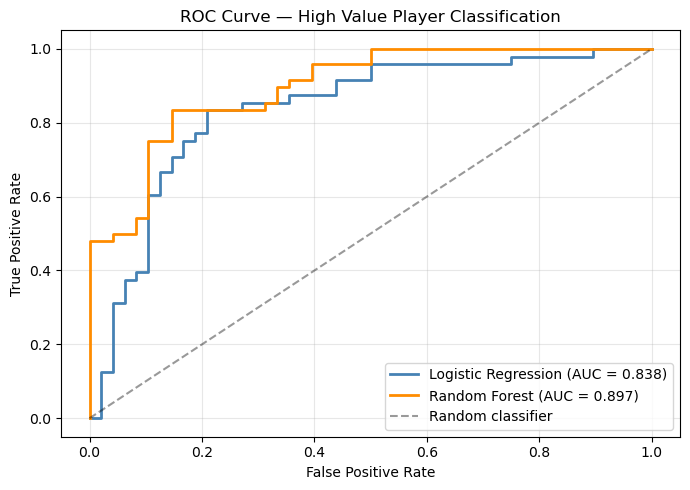

In [278]:
# ── CELLULE 11 : ROC Curve ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
for name, model, color in [
    ("Logistic Regression", best_lr, "steelblue"),
    ("Random Forest",       best_rf, "darkorange")
]:
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, color=color, lw=2, label=f"{name} (AUC = {auc:.3f})")
ax.plot([0,1],[0,1], 'k--', alpha=0.4, label="Random classifier")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — High Value Player Classification")
ax.legend(loc="lower right")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("roc_curve.png", dpi=150, bbox_inches='tight')
plt.show()

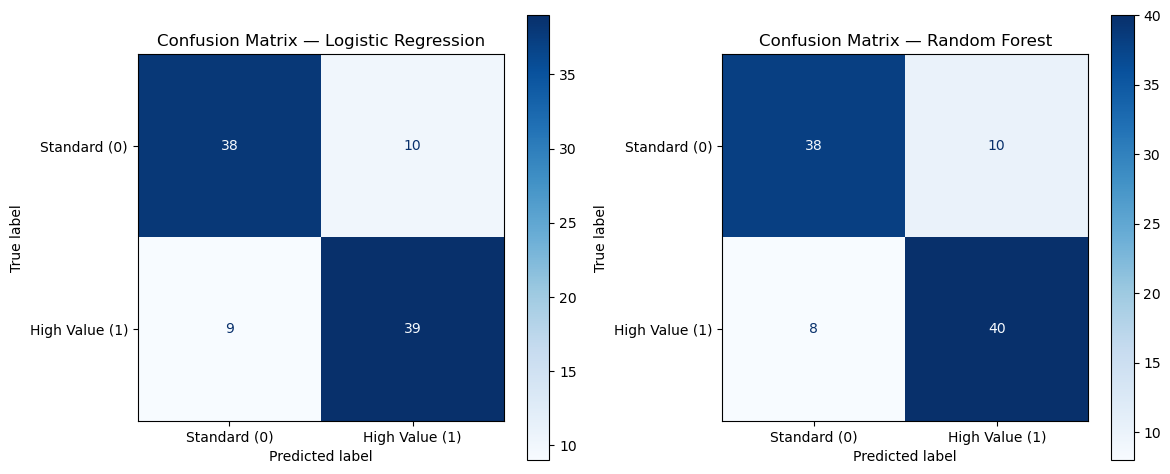

In [280]:
# ── CELLULE 12 : Confusion Matrix ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (name, model) in zip(axes, [
    ("Logistic Regression", best_lr),
    ("Random Forest",       best_rf)
]):
    ConfusionMatrixDisplay.from_estimator(
        model, X_test, y_test,
        display_labels=["Standard (0)", "High Value (1)"],
        cmap="Blues", ax=ax
    )
    ax.set_title(f"Confusion Matrix — {name}")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

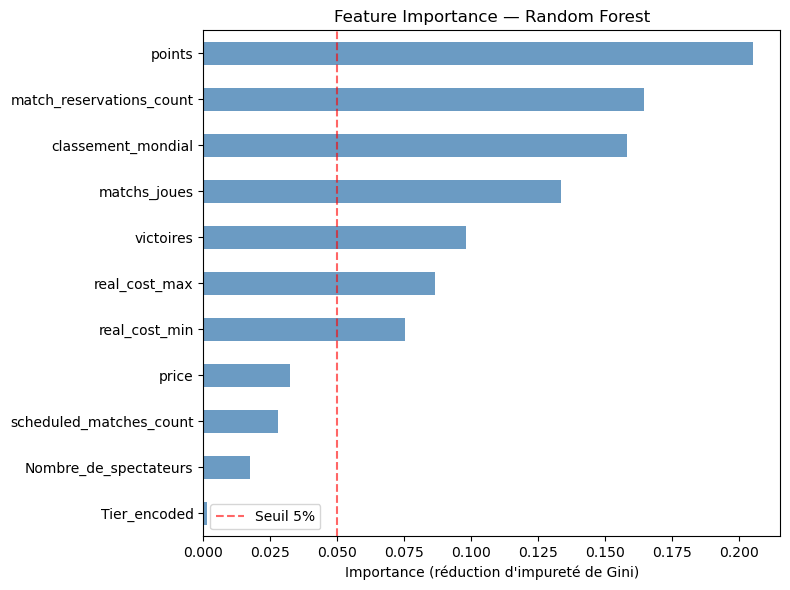

In [282]:
# ── CELLULE 13 : Feature Importance ───────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
rf_model    = best_rf.named_steps['clf']
importances = pd.Series(rf_model.feature_importances_, index=FEATURES)
importances = importances.sort_values(ascending=True)
importances.plot(kind='barh', ax=ax, color='steelblue', alpha=0.8)
ax.set_title("Feature Importance — Random Forest")
ax.set_xlabel("Importance (réduction d'impureté de Gini)")
ax.axvline(x=0.05, color='red', linestyle='--', alpha=0.6, label="Seuil 5%")
ax.legend()
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, bbox_inches='tight')
plt.show()

 Feature Importance

Les features les plus discriminantes pour identifier un "high value player" sont
les métriques de performance pure (points FIP, victoires, matchs joués, classement)
et les indicateurs économiques du tournoi (real_cost_max, match_reservations_count).

Fait notable : Tier_encoded apparaît avec une importance très faible, suggérant que
la catégorie administrative du joueur prédit moins bien son statut "high value" que
ses performances réelles — cohérent avec la définition d'IPJ_score basée sur des
métriques objectives.

In [284]:
# ── CELLULE 14 : Tableau comparatif final ─────────────────────────────
results = []
for name, model in [("Logistic Regression", best_lr), ("Random Forest", best_rf)]:
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    results.append({
        "Modèle"   : name,
        "Accuracy" : float(f"{accuracy_score(y_test, y_pred):.3f}"),
        "Precision": float(f"{precision_score(y_test, y_pred):.3f}"),
        "Recall"   : float(f"{recall_score(y_test, y_pred):.3f}"),
        "F1-score" : float(f"{f1_score(y_test, y_pred):.3f}"),
        "ROC-AUC"  : float(f"{roc_auc_score(y_test, y_proba):.3f}")
    })

df_results = pd.DataFrame(results).set_index("Modèle")

df_results.style \
    .format("{:.3f}") \
    .background_gradient(cmap="Blues", subset=["Accuracy","Precision","Recall","F1-score","ROC-AUC"]) \
    .highlight_max(axis=0, props="font-weight: bold; color: darkblue;") \
    .set_caption("📊 Comparaison des modèles — Classification High Value Player") \
    .set_table_styles([
        {"selector": "caption",
         "props": [("font-size", "14px"), ("font-weight", "bold"), ("padding", "10px")]},
        {"selector": "th",
         "props": [("background-color", "#2c3e50"), ("color", "white"),
                   ("font-size", "12px"), ("text-align", "center"), ("padding", "8px")]},
        {"selector": "td",
         "props": [("text-align", "center"), ("padding", "8px"), ("font-size", "12px")]},
    ])  
from IPython.display import display
display(df_results.style \
    .format("{:.3f}") \

)

,Accuracy,Precision,Recall,F1-score,ROC-AUC
Modèle,,,,,
Logistic Regression,0.802,0.796,0.812,0.804,0.838
Random Forest,0.812,0.800,0.833,0.816,0.897


## Partie D — Regression : Prediction du classement mondial

In [286]:
# ── Features de régression (sans les colonnes qui composent IPJ_score) ──
# IPJ_score = WINS_per_match(×0.4) + engagement_rate(×0.3) + prize_avg(×0.3)
# → On exclut : WINS_per_match, likes, Abonnes_Instagram, prize_money_min/max
# → On garde des features indépendantes de la formule IPJ

FEATURES_REG = [
    'matchs_joues',
    'victoires',
    'points',
    'price',
    'real_cost_min',
    'real_cost_max',
    'Nombre_de_spectateurs',
    'scheduled_matches_count',
    'match_reservations_count',
    'Tier_encoded',
    'classement_mondial'
]

X_reg = df[FEATURES_REG].copy()
y_reg = df['IPJ_score'].copy()

print(f"Shape X_reg : {X_reg.shape}")
print(f"\nDistribution y (IPJ_score) :")
print(y_reg.describe().round(2))

Shape X_reg : (480, 11)

Distribution y (IPJ_score) :
count    480.00
mean      41.73
std        6.43
min       31.05
25%       38.10
50%       40.55
75%       45.05
max       66.50
Name: IPJ_score, dtype: float64


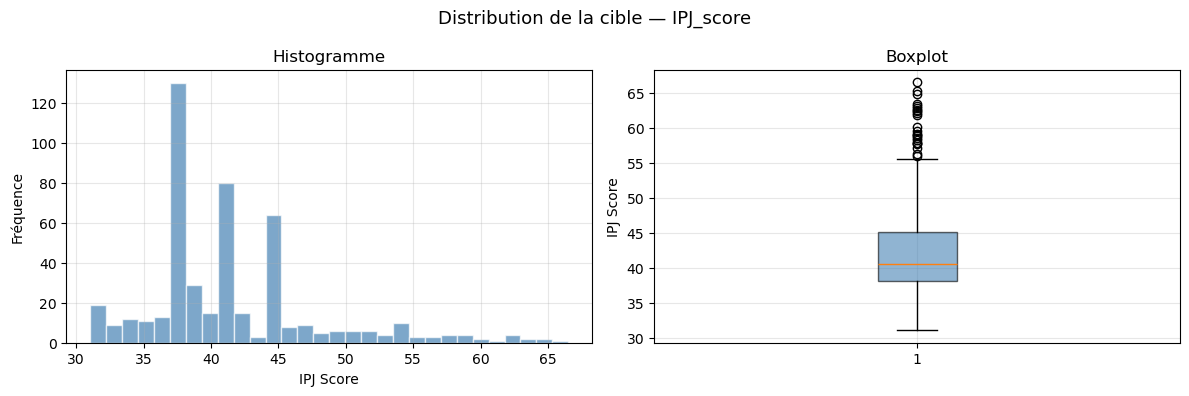


Skewness : 1.338
→ Distribution asymétrique : transformation log recommandée


In [288]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Distribution de la cible — IPJ_score", fontsize=13)

axes[0].hist(y_reg, bins=30, color='steelblue', alpha=0.7, edgecolor='white')
axes[0].set_title("Histogramme")
axes[0].set_xlabel("IPJ Score")
axes[0].set_ylabel("Fréquence")
axes[0].grid(alpha=0.3)

axes[1].boxplot(y_reg, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title("Boxplot")
axes[1].set_ylabel("IPJ Score")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("distribution_cible_regression.png", dpi=150, bbox_inches='tight')
plt.show()

skew = y_reg.skew()
print(f"\nSkewness : {skew:.3f}")
if abs(skew) > 1:
    print("→ Distribution asymétrique : transformation log recommandée")
else:
    print("→ Distribution acceptable : pas de transformation nécessaire")

Skewness original  : 1.338
Skewness après log : 0.868


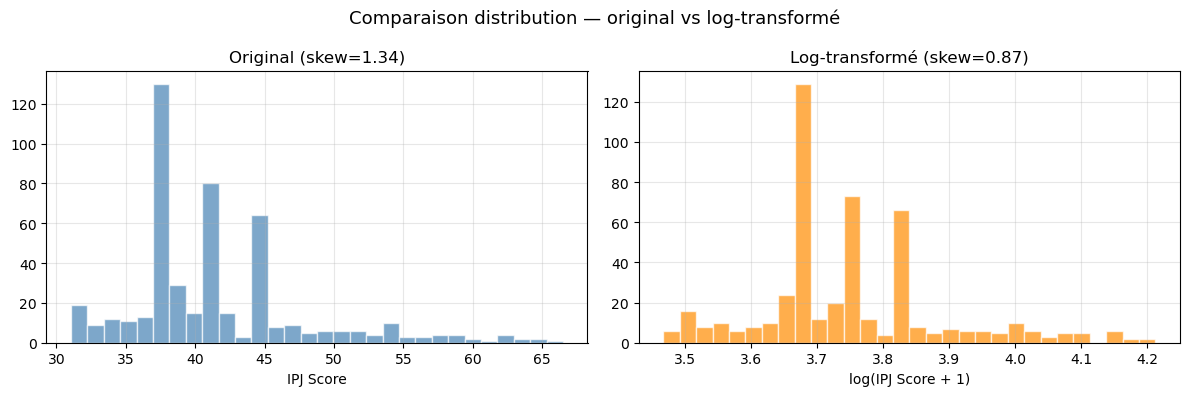


Train : 384 lignes | Test : 96 lignes
y_train — moyenne : 3.7461 | std : 0.1394
y_test  — moyenne : 3.7390 | std : 0.1465


In [290]:
# ── CORRECTION : log1p appliqué AVANT le train/test split ──────────
# ERREUR originale : le split était fait sur y original (~41),
# puis y_reg était remplacé par log(y) (~3.7) SANS refaire le split.
# Résultat : y_train_r gardait les valeurs ~41 mais la CV utilisait ~3.7
# → R² = -68 694 (totalement incohérent).

y_reg_log = np.log1p(y_reg)

print(f"Skewness original  : {y_reg.skew():.3f}")
print(f"Skewness après log : {y_reg_log.skew():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Comparaison distribution — original vs log-transformé", fontsize=13)

axes[0].hist(y_reg, bins=30, color='steelblue', alpha=0.7, edgecolor='white')
axes[0].set_title(f"Original (skew={y_reg.skew():.2f})")
axes[0].set_xlabel("IPJ Score")
axes[0].grid(alpha=0.3)

axes[1].hist(y_reg_log, bins=30, color='darkorange', alpha=0.7, edgecolor='white')
axes[1].set_title(f"Log-transformé (skew={y_reg_log.skew():.2f})")
axes[1].set_xlabel("log(IPJ Score + 1)")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("log_transform.png", dpi=150, bbox_inches='tight')
plt.show()

# ── Train/Test split fait ICI sur y log-transformé ───────────────────
y_reg_final = y_reg_log.copy()   # cible finale = log(IPJ_score)

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg_final, test_size=0.20, random_state=42
)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

print(f"\nTrain : {X_train_r.shape[0]} lignes | Test : {X_test_r.shape[0]} lignes")
print(f"y_train — moyenne : {y_train_r.mean():.4f} | std : {y_train_r.std():.4f}")
print(f"y_test  — moyenne : {y_test_r.mean():.4f} | std : {y_test_r.std():.4f}")

## Modèle 1 — Ridge Regression

**Intuition :** Extension de la régression linéaire qui ajoute une pénalité L2
sur les coefficients (somme des carrés). Cela force les coefficients à rester
petits et évite l'overfitting quand les features sont corrélées entre elles
(ex : victoires et WINS_per_match sont liées).

**Paramètres clés :**
- `alpha` : force de la régularisation — petit alpha ≈ régression linéaire classique,
  grand alpha = coefficients très contraints vers zéro

**Hypothèses :**
- "Relation linéaire entre les features et log(IPJ_score)
- - Résidus normalement distribués et homoscédastiques (variance constante)
- Pas de multicolinéarité parfaite entre features

**Limitations :**
- Ne capte pas les relations non-linéaires (ex : un joueur peut progresser
  de façon exponentielle dans le classement après un certain seuil de victoires)
- Tous les coefficients restent non nuls (contrairement à Lasso)

**Justification du choix :** Modèle baseline interprétable "les coefficients indiquent directement l'effet d'une unité supplémentaire
de chaque feature sur log(IPJ_score)."t. Robuste à la multicolinéarité grâce à la régularisation L2.

## Modèle 2 — Random Forest Regressor

**Intuition :** Même principe qu'en classification (bagging + feature randomness)
mais la prédiction finale est la **moyenne** des prédictions de N arbres
(au lieu du vote majoritaire). Chaque arbre prédit une valeur de classement,
et on moyenne le tout pour réduire la variance.

**Différence avec Random Forest Classifier :**
- Classifier → vote majoritaire → classe (0 ou 1)
- Regressor → moyenne des prédictions → valeur continue (ex : rang 47)

**Paramètres clés tunés :**
- `n_estimators` : nombre d'arbres
- `max_depth` : profondeur maximale — contrôle l'overfitting
- `min_samples_split` / `min_samples_leaf` : taille minimale des noeuds

**Hypothèses :** Aucune hypothèse distributionnelle. Non-paramétrique.

**Limitations :**
- Ne peut pas extrapoler au-delà des valeurs observées (si un joueur a
  un classement > max du train, le modèle sature)
- Moins interprétable que Ridge

**Justification du choix :** Capte les interactions non-linéaires entre features
(ex :- "l'effet de classement_mondial sur log(IPJ_score) varie selon le Tier"
Fournit une feature importance native pour expliquer les prédictions.

In [292]:
# ── CORRECTION : les search_ridge et search_rfr sont définis ICI ─────
# ERREUR originale : ces objets n'étaient nulle part dans le notebook,
# ce qui rendait le notebook non reproductible.

# ── Pipeline Ridge ────────────────────────────────────────────────────
pipe_ridge = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    Ridge())
])

param_ridge = {
    'clf__alpha': [0.001, 0.01, 0.1, 1, 10, 50, 100, 500, 1000]
}

search_ridge = RandomizedSearchCV(
    pipe_ridge,
    param_distributions=param_ridge,
    n_iter=9, cv=kf, scoring='r2',
    random_state=42, n_jobs=-1
)
search_ridge.fit(X_train_r, y_train_r)

print(f"Ridge — Meilleur alpha : {search_ridge.best_params_}")
print(f"Ridge — Meilleur R² CV : {search_ridge.best_score_:.4f}")

# ── Pipeline Random Forest Regressor ─────────────────────────────────
pipe_rfr = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    RandomForestRegressor(random_state=42))
])

param_rfr = {
    'clf__n_estimators'     : [100, 200, 300],
    'clf__max_depth'        : [3, 5, 7, None],
    'clf__min_samples_split': [2, 5, 10],
    'clf__min_samples_leaf' : [1, 2, 4]
}

search_rfr = RandomizedSearchCV(
    pipe_rfr,
    param_distributions=param_rfr,
    n_iter=20, cv=kf, scoring='r2',
    random_state=42, n_jobs=-1
)
search_rfr.fit(X_train_r, y_train_r)

print(f"\nRandom Forest — Meilleurs params : {search_rfr.best_params_}")
print(f"Random Forest — Meilleur R² CV   : {search_rfr.best_score_:.4f}")

Ridge — Meilleur alpha : {'clf__alpha': 100}
Ridge — Meilleur R² CV : 0.1291

Random Forest — Meilleurs params : {'clf__n_estimators': 300, 'clf__min_samples_split': 10, 'clf__min_samples_leaf': 4, 'clf__max_depth': 7}
Random Forest — Meilleur R² CV   : 0.1731


In [294]:
best_ridge = search_ridge.best_estimator_
best_rfr   = search_rfr.best_estimator_

print("=" * 55)
for name, model in [("RIDGE REGRESSION", best_ridge),
                    ("RANDOM FOREST REGRESSOR", best_rfr)]:
    y_pred = model.predict(X_test_r)

    mse  = mean_squared_error(y_test_r, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_test_r, y_pred)
    r2   = r2_score(y_test_r, y_pred)

    cv_r2 = cross_val_score(model, X_reg, y_reg_final, cv=kf, scoring='r2')

    print(f"\n{'='*55}\n  {name}\n{'='*55}")
    print(f"  MSE        : {mse:.5f}  (unités log²)")
    print(f"  RMSE       : {rmse:.5f}  (unités log — erreur moy.)")
    print(f"  MAE        : {mae:.5f}")
    print(f"  R²         : {r2:.4f}")
    print(f"  R² CV mean : {cv_r2.mean():.4f} ± {cv_r2.std():.4f}")

    # Interprétation back-transform
    y_pred_original = np.expm1(y_pred)
    y_test_original = np.expm1(y_test_r)
    rmse_orig = np.sqrt(mean_squared_error(y_test_original, y_pred_original))
    mae_orig  = mean_absolute_error(y_test_original, y_pred_original)
    print(f"  RMSE (IPJ original) : {rmse_orig:.2f} points IPJ")
    print(f"  MAE  (IPJ original) : {mae_orig:.2f} points IPJ")

print("=" * 55)


  RIDGE REGRESSION
  MSE        : 0.01737  (unités log²)
  RMSE       : 0.13181  (unités log — erreur moy.)
  MAE        : 0.09157
  R²         : 0.1815
  R² CV mean : 0.1650 ± 0.0245
  RMSE (IPJ original) : 6.15 points IPJ
  MAE  (IPJ original) : 4.05 points IPJ

  RANDOM FOREST REGRESSOR
  MSE        : 0.02048  (unités log²)
  RMSE       : 0.14311  (unités log — erreur moy.)
  MAE        : 0.09316
  R²         : 0.0351
  R² CV mean : 0.1154 ± 0.0834
  RMSE (IPJ original) : 6.60 points IPJ
  MAE  (IPJ original) : 4.17 points IPJ


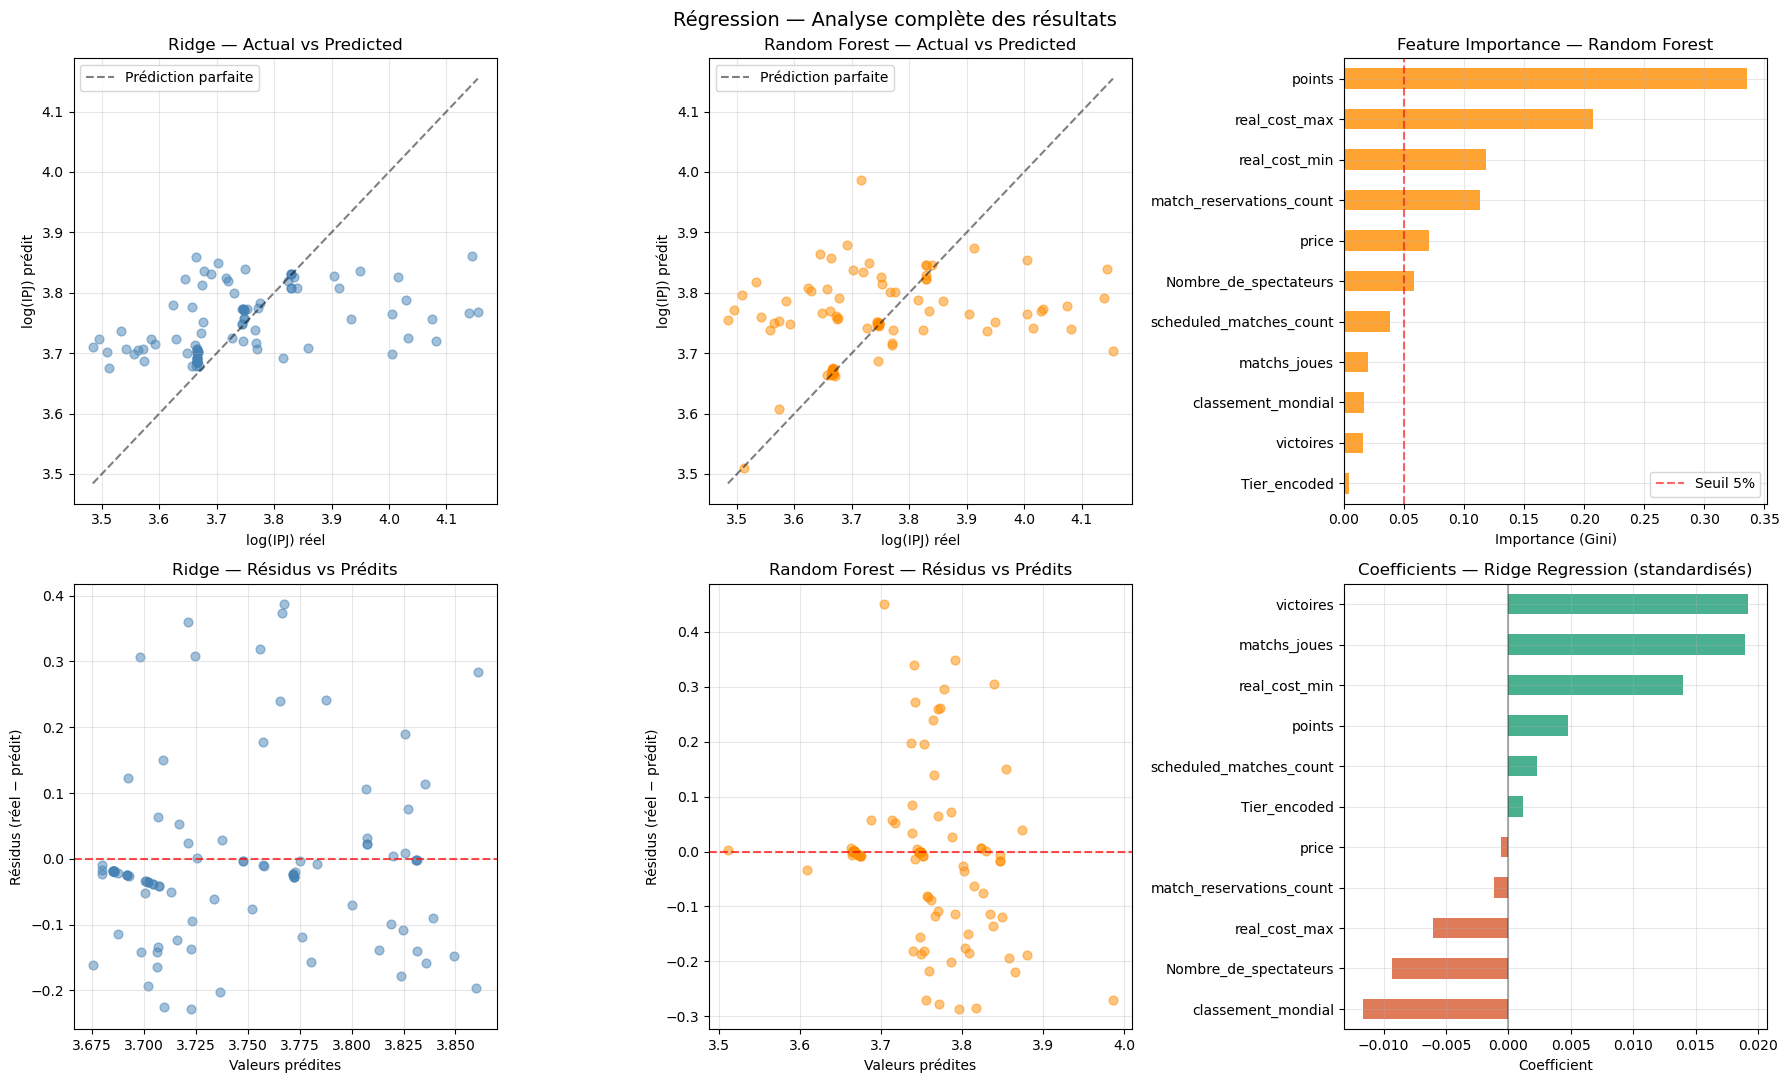

In [296]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle("Régression — Analyse complète des résultats", fontsize=14)

models_reg = [("Ridge", best_ridge, "steelblue"),
              ("Random Forest", best_rfr, "darkorange")]

for col, (name, model, color) in enumerate(models_reg):
    y_pred  = model.predict(X_test_r)
    residus = y_test_r - y_pred

    # ── Plot 1 : Actual vs Predicted ────────────────────────────────
    ax = axes[0][col]
    ax.scatter(y_test_r, y_pred, alpha=0.5, color=color, s=40)
    lims = [min(y_test_r.min(), y_pred.min()),
            max(y_test_r.max(), y_pred.max())]
    ax.plot(lims, lims, 'k--', alpha=0.5, label="Prédiction parfaite")
    ax.set_xlabel("log(IPJ) réel")
    ax.set_ylabel("log(IPJ) prédit")
    ax.set_title(f"{name} — Actual vs Predicted")
    ax.legend()
    ax.grid(alpha=0.3)

    # ── Plot 2 : Résidus vs Prédits ─────────────────────────────────
    ax = axes[1][col]
    ax.scatter(y_pred, residus, alpha=0.5, color=color, s=40)
    ax.axhline(y=0, color='red', linestyle='--', alpha=0.7)
    ax.set_xlabel("Valeurs prédites")
    ax.set_ylabel("Résidus (réel − prédit)")
    ax.set_title(f"{name} — Résidus vs Prédits")
    ax.grid(alpha=0.3)

# ── Plot 3 : Feature Importance RF ──────────────────────────────────
ax = axes[0][2]
rf_model_r = best_rfr.named_steps['clf']
importances_r = pd.Series(
    rf_model_r.feature_importances_,
    index=FEATURES_REG
).sort_values(ascending=True)
importances_r.plot(kind='barh', ax=ax, color='darkorange', alpha=0.8)
ax.axvline(x=0.05, color='red', linestyle='--', alpha=0.6, label="Seuil 5%")
ax.set_title("Feature Importance — Random Forest")
ax.set_xlabel("Importance (Gini)")
ax.legend()
ax.grid(alpha=0.3)

# ── Plot 4 : Coefficients Ridge ──────────────────────────────────────
ax = axes[1][2]
ridge_model = best_ridge.named_steps['clf']
coefs = pd.Series(
    ridge_model.coef_,
    index=FEATURES_REG
).sort_values(ascending=True)
colors_coef = ['#D85A30' if c < 0 else '#1D9E75' for c in coefs]
coefs.plot(kind='barh', ax=ax, color=colors_coef, alpha=0.8)
ax.axvline(x=0, color='black', linestyle='-', alpha=0.3)
ax.set_title("Coefficients — Ridge Regression (standardisés)")
ax.set_xlabel("Coefficient")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("regression_results.png", dpi=150, bbox_inches='tight')
plt.show()

In [298]:
results_reg = []
for name, model in [("Ridge Regression", best_ridge),
                    ("Random Forest Regressor", best_rfr)]:
    y_pred  = model.predict(X_test_r)
    cv_r2   = cross_val_score(model, X_reg, y_reg_final, cv=kf, scoring='r2')

    y_pred_orig = np.expm1(y_pred)
    y_test_orig = np.expm1(y_test_r)

    results_reg.append({
        "Modèle"           : name,
        "MSE (log)"        : round(mean_squared_error(y_test_r, y_pred), 5),
        "RMSE (log)"       : round(np.sqrt(mean_squared_error(y_test_r, y_pred)), 5),
        "MAE (log)"        : round(mean_absolute_error(y_test_r, y_pred), 5),
        "R²"               : round(r2_score(y_test_r, y_pred), 4),
        "R² CV mean"       : round(cv_r2.mean(), 4),
        "R² CV std"        : round(cv_r2.std(), 4),
        "RMSE (IPJ réel)"  : round(np.sqrt(mean_squared_error(y_test_orig, y_pred_orig)), 2),
        "MAE (IPJ réel)"   : round(mean_absolute_error(y_test_orig, y_pred_orig), 2),
    })

df_reg = pd.DataFrame(results_reg).set_index("Modèle")
print(df_reg.to_string())

df_reg.style \
    .format({"MSE (log)": "{:.5f}", "RMSE (log)": "{:.5f}", "MAE (log)": "{:.5f}",
             "R²": "{:.4f}", "R² CV mean": "{:.4f}", "R² CV std": "{:.4f}",
             "RMSE (IPJ réel)": "{:.2f}", "MAE (IPJ réel)": "{:.2f}"}) \
    .background_gradient(cmap="Blues", subset=["R²", "R² CV mean"]) \
    .background_gradient(cmap="RdYlGn_r", subset=["MSE (log)", "RMSE (log)", "MAE (log)"]) \
    .highlight_min(axis=0, subset=["MSE (log)","RMSE (log)","MAE (log)"],
                   props="font-weight: bold; color: darkgreen;") \
    .highlight_max(axis=0, subset=["R²", "R² CV mean"],
                   props="font-weight: bold; color: darkblue;") \
    .set_caption("Comparaison des modèles de régression — Prédiction IPJ_score") \
    .set_table_styles([
        {"selector": "caption",
         "props": [("font-size", "14px"), ("font-weight", "bold"), ("padding", "10px")]},
        {"selector": "th",
         "props": [("background-color", "#2c3e50"), ("color", "white"),
                   ("font-size", "12px"), ("text-align", "center"), ("padding", "8px")]},
        {"selector": "td",
         "props": [("text-align", "center"), ("padding", "8px"), ("font-size", "12px")]},
    ])

                         MSE (log)  RMSE (log)  MAE (log)      R²  R² CV mean  R² CV std  RMSE (IPJ réel)  MAE (IPJ réel)
Modèle                                                                                                                   
Ridge Regression           0.01737     0.13181    0.09157  0.1815      0.1650     0.0245             6.15            4.05
Random Forest Regressor    0.02048     0.14311    0.09316  0.0351      0.1154     0.0834             6.60            4.17


,MSE (log),RMSE (log),MAE (log),R²,R² CV mean,R² CV std,RMSE (IPJ réel),MAE (IPJ réel)
Modèle,,,,,,,,
Ridge Regression,0.01737,0.13181,0.09157,0.1815,0.1650,0.0245,6.15,4.05
Random Forest Regressor,0.02048,0.14311,0.09316,0.0351,0.1154,0.0834,6.60,4.17


Advanced Objectives : Anomaly Detection

In [300]:
# ── ADVANCED OBJECTIVES : Anomaly Detection ──────────────────────
# Ajoute ces imports en haut de la cellule (ou dans une nouvelle cellule)

from sklearn.ensemble import IsolationForest
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

In [302]:
# ── Calcul des KPIs (reprend les formules de tes fiches) ─────────
df['TVJ']  = (df['victoires'] / df['matchs_joues']) * 100
df['TEI']  = (df['likes'] / df['Abonnes_Instagram_Novembre_2025']) * 100
df['TRT']  = (df['match_reservations_count'] / df['scheduled_matches_count']) * 100
df['cout_moyen'] = (df['real_cost_min'] + df['real_cost_max']) / 2
df['prize_moyen'] = (df['prize_money_min'] + df['prize_money_max']) / 2
df['RPCO'] = (df['prize_moyen'] / df['cout_moyen']) * 100
df['CMMJ'] = df['cout_moyen'] / df['matchs_joues']

# ── Feature matrix pour la détection d'anomalies ─────────────────
features_anomaly = [
    'TVJ', 'TEI', 'TRT', 'RPCO', 'CMMJ',
    'points', 'Nombre_de_spectateurs',
    'cout_moyen', 'prize_moyen'
]

X_anom = df[features_anomaly].copy()

# Vérification
print("Shape feature matrix :", X_anom.shape)
print("Valeurs manquantes :", X_anom.isnull().sum().sum())
print(X_anom.describe().round(2))


Shape feature matrix : (480, 9)
Valeurs manquantes : 0
          TVJ     TEI     TRT    RPCO     CMMJ    points  \
count  480.00  480.00  480.00  480.00   480.00    480.00   
mean    81.75    1.07   92.01   64.72  6739.67  22228.48   
std      7.58    0.85    8.02   30.56  1167.41  11920.01   
min     74.71    0.09   74.26   22.97  3851.99      0.00   
25%     74.93    0.45   87.13   55.77  6435.64  12008.75   
50%     79.61    0.75   89.11   55.77  6842.11  21467.50   
75%     86.43    1.63  100.00   61.27  7471.26  33650.00   
max     93.07    4.80  117.44  207.11  9734.22  40000.00   

       Nombre_de_spectateurs  cout_moyen  prize_moyen  
count                 480.00      480.00       480.00  
mean                11802.68   623318.46    390250.26  
std                  1639.96   103905.61    152224.68  
min                  9585.00   389050.88    167123.00  
25%                  9700.00   587177.75    362500.00  
50%                 12141.00   650000.00    362500.00  
75%         

In [230]:
# ── Standardisation (obligatoire pour DBSCAN, conseillé pour IF) ─
scaler_anom = StandardScaler()
X_anom_scaled = scaler_anom.fit_transform(X_anom)

print("Données normalisées — mean ~0, std ~1")
print(X_anom_scaled.mean(axis=0).round(3))

Données normalisées — mean ~0, std ~1
[-0.  0.  0. -0.  0.  0.  0. -0. -0.]


In [304]:
# ── Isolation Forest ─────────────────────────────────────────────
iso_forest = IsolationForest(
    n_estimators=200,       # nb d'arbres (plus = plus stable)
    contamination=0.05,     # % d'anomalies attendues (~5%)
    random_state=42,
    n_jobs=-1
)

df['IF_label'] = iso_forest.fit_predict(X_anom_scaled)
# -1 = anomalie   |   1 = normal
df['IF_score']  = iso_forest.decision_function(X_anom_scaled)
# score négatif = plus anormal

n_anomalies = (df['IF_label'] == -1).sum()
print(f"Anomalies détectées : {n_anomalies} / {len(df)}")
print(f"Pourcentage : {n_anomalies/len(df)*100:.1f}%")

Anomalies détectées : 24 / 480
Pourcentage : 5.0%


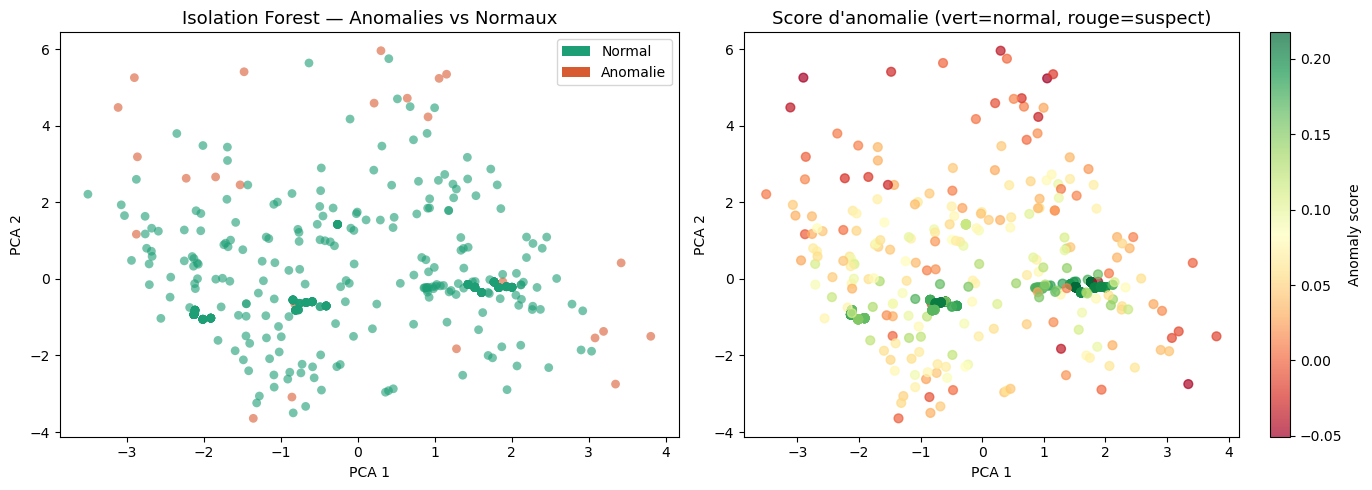

Variance expliquée PCA : 54.9%


In [234]:
# ── PCA 2D pour visualiser ────────────────────────────────────────
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_anom_scaled)

df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1 : Anomalies vs Normaux
colors = df['IF_label'].map({1: '#1D9E75', -1: '#D85A30'})
axes[0].scatter(df['PCA1'], df['PCA2'], c=colors, alpha=0.6, s=40, edgecolors='none')
axes[0].set_title('Isolation Forest — Anomalies vs Normaux', fontsize=13)
axes[0].set_xlabel('PCA 1')
axes[0].set_ylabel('PCA 2')
from matplotlib.patches import Patch
legend_elem = [Patch(facecolor='#1D9E75', label='Normal'),
               Patch(facecolor='#D85A30', label='Anomalie')]
axes[0].legend(handles=legend_elem)

# Plot 2 : Score d'anomalie (heatmap continue)
sc = axes[1].scatter(df['PCA1'], df['PCA2'], c=df['IF_score'],
                     cmap='RdYlGn', alpha=0.7, s=40)
axes[1].set_title('Score d\'anomalie (vert=normal, rouge=suspect)', fontsize=13)
axes[1].set_xlabel('PCA 1')
axes[1].set_ylabel('PCA 2')
plt.colorbar(sc, ax=axes[1], label='Anomaly score')

plt.tight_layout()
plt.savefig('isolation_forest_results.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Variance expliquée PCA : {pca.explained_variance_ratio_.sum()*100:.1f}%")

In [306]:
# ── DBSCAN ────────────────────────────────────────────────────────
dbscan = DBSCAN(
    eps=2.5,          # rayon de voisinage (à tuner selon tes données)
    min_samples=5,    # min de voisins pour former un cluster
    metric='euclidean'
)

df['DBSCAN_label'] = dbscan.fit_predict(X_anom_scaled)
# -1 = bruit/anomalie   |   0,1,2... = clusters

n_clusters = len(set(df['DBSCAN_label'])) - (1 if -1 in df['DBSCAN_label'].values else 0)
n_noise    = (df['DBSCAN_label'] == -1).sum()

print(f"Clusters trouvés     : {n_clusters}")
print(f"Points bruit (anomalies) : {n_noise} / {len(df)}")
print(df['DBSCAN_label'].value_counts())

Clusters trouvés     : 2
Points bruit (anomalies) : 12 / 480
DBSCAN_label
 0    463
-1     12
 1      5
Name: count, dtype: int64


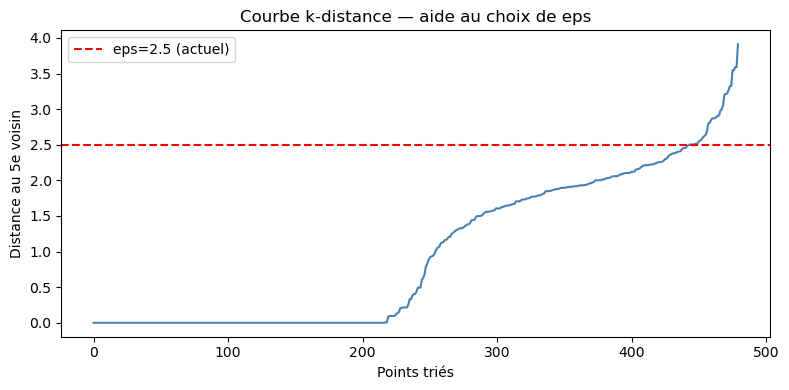

Le 'coude' de la courbe indique le bon eps


In [238]:
# ── Trouver le bon eps avec la courbe k-distance ──────────────────
from sklearn.neighbors import NearestNeighbors

k = 5
nbrs = NearestNeighbors(n_neighbors=k).fit(X_anom_scaled)
distances, _ = nbrs.kneighbors(X_anom_scaled)
distances = np.sort(distances[:, k-1], axis=0)

plt.figure(figsize=(8, 4))
plt.plot(distances, color='steelblue', linewidth=1.5)
plt.axhline(y=2.5, color='red', linestyle='--', label='eps=2.5 (actuel)')
plt.title('Courbe k-distance — aide au choix de eps')
plt.xlabel('Points triés')
plt.ylabel(f'Distance au {k}e voisin')
plt.legend()
plt.tight_layout()
plt.show()
print("Le 'coude' de la courbe indique le bon eps")

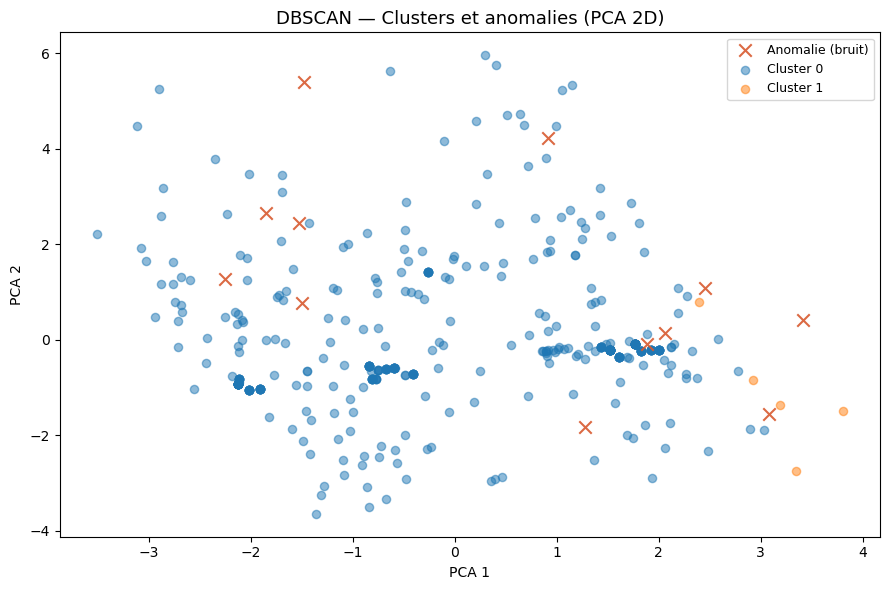

In [314]:
# ── Recalcul PCA si pas encore fait ─────────────────────────────
from sklearn.decomposition import PCA

if 'PCA1' not in df.columns:
    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X_anom_scaled)
    df['PCA1'] = X_pca[:, 0]
    df['PCA2'] = X_pca[:, 1]

# ── Visualisation DBSCAN ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 6))
unique_labels = sorted(df['DBSCAN_label'].unique())
palette = plt.cm.tab10.colors

for label in unique_labels:
    mask = df['DBSCAN_label'] == label
    if label == -1:
        ax.scatter(df.loc[mask, 'PCA1'], df.loc[mask, 'PCA2'],
                   c='#D85A30', marker='x', s=80, alpha=0.9,
                   linewidths=1.5, label='Anomalie (bruit)', zorder=5)
    else:
        color = palette[label % len(palette)]
        ax.scatter(df.loc[mask, 'PCA1'], df.loc[mask, 'PCA2'],
                   c=[color], alpha=0.5, s=35, label=f'Cluster {label}')

ax.set_title('DBSCAN — Clusters et anomalies (PCA 2D)', fontsize=13)
ax.set_xlabel('PCA 1')
ax.set_ylabel('PCA 2')
ax.legend(loc='best', fontsize=9)
plt.tight_layout()
plt.savefig('dbscan_results.png', dpi=150, bbox_inches='tight')
plt.show()

In [316]:
# ── Comparaison des deux méthodes ────────────────────────────────
from sklearn.metrics import cohen_kappa_score

# Binaire : 1=anomalie, 0=normal
if_bin = (df['IF_label'] == -1).astype(int)
db_bin = (df['DBSCAN_label'] == -1).astype(int)

both_anomaly = ((if_bin == 1) & (db_bin == 1)).sum()
only_if      = ((if_bin == 1) & (db_bin == 0)).sum()
only_db      = ((if_bin == 0) & (db_bin == 1)).sum()
neither      = ((if_bin == 0) & (db_bin == 0)).sum()

print("═══ Comparaison IF vs DBSCAN ═══")
print(f"Anomalies détectées par LES DEUX : {both_anomaly}")
print(f"Anomalies uniquement IF          : {only_if}")
print(f"Anomalies uniquement DBSCAN      : {only_db}")
print(f"Normal pour les deux             : {neither}")
print(f"Kappa (accord) : {cohen_kappa_score(if_bin, db_bin):.3f}")

# Crosstab visuel
pd.crosstab(
    df['IF_label'].map({1:'Normal IF', -1:'Anomalie IF'}),
    df['DBSCAN_label'].map(lambda x: 'Anomalie DB' if x==-1 else f'Cluster {x}'),
    margins=True )

═══ Comparaison IF vs DBSCAN ═══
Anomalies détectées par LES DEUX : 8
Anomalies uniquement IF          : 16
Anomalies uniquement DBSCAN      : 4
Normal pour les deux             : 452
Kappa (accord) : 0.425


DBSCAN_label,Anomalie DB,Cluster 0,Cluster 1,All
IF_label,,,,
Anomalie IF,8,13,3,24
Normal IF,4,450,2,456
All,12,463,5,480


In [310]:
# ── Analyse des anomalies — interprétation métier ────────────────
# Anomalies confirmées par les DEUX méthodes (plus fiables)
df['is_anomaly'] = ((df['IF_label'] == -1) & (df['DBSCAN_label'] == -1)).astype(int)

anomalies_df = df[df['is_anomaly'] == 1]
normaux_df   = df[df['is_anomaly'] == 0]

print(f"\n{'═'*55}")
print(f"  PROFIL DES {len(anomalies_df)} ANOMALIES CONFIRMÉES")
print(f"{'═'*55}")

kpis_display = ['TVJ','TEI','TRT','RPCO','CMMJ',
                'Nombre_de_spectateurs','cout_moyen','prize_moyen']

comparison = pd.DataFrame({
    'Anomalies (moy)': anomalies_df[kpis_display].mean().round(2),
    'Normaux (moy)'  : normaux_df[kpis_display].mean().round(2),
})
comparison['Écart %'] = (
    (comparison['Anomalies (moy)'] - comparison['Normaux (moy)'])
    / comparison['Normaux (moy)'] * 100
).round(1)

print(comparison.to_string())

# Répartition par Tier
print("\nRépartition des anomalies par Tier :")
print(anomalies_df['Tier'].value_counts())



═══════════════════════════════════════════════════════
  PROFIL DES 8 ANOMALIES CONFIRMÉES
═══════════════════════════════════════════════════════
                       Anomalies (moy)  Normaux (moy)  Écart %
TVJ                              78.23          81.81     -4.4
TEI                               2.42           1.05    130.5
TRT                              98.63          91.90      7.3
RPCO                            108.59          63.98     69.7
CMMJ                           7013.92        6735.03      4.1
Nombre_de_spectateurs         11828.25       11802.25      0.2
cout_moyen                   626531.62      623264.00      0.5
prize_moyen                  617902.94      386391.74     59.9

Répartition des anomalies par Tier :
Tier
Top10       6
Hors Top    2
Name: count, dtype: int64


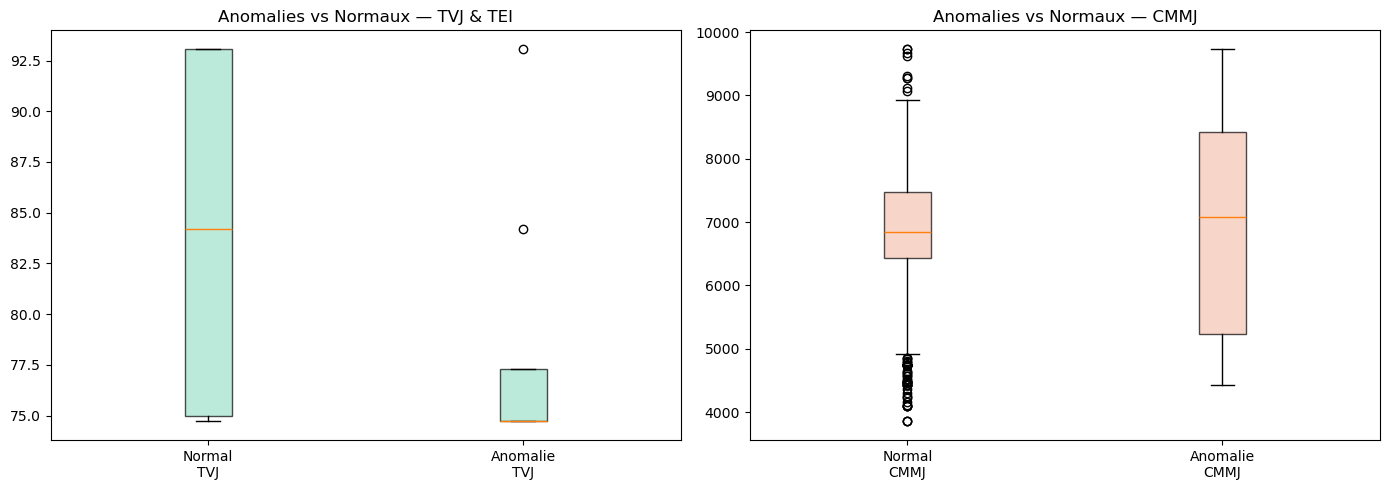


╔══════════════════════════════════════════════════╗
║  RÉSUMÉ ADVANCED OBJECTIVES — Anomaly Detection ║
╠══════════════════════════════════════════════════╣
║  Méthode 1 : Isolation Forest    ✓              ║
║  Méthode 2 : DBSCAN              ✓              ║
║  Anomalies IF  :  24 lignes             ║
║  Anomalies DB  :  12 lignes             ║
║  Confirmées (2/2) :   8 lignes          ║
╚══════════════════════════════════════════════════╝


In [318]:
# ── Heatmap comparative Anomalies vs Normaux ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplots comparatifs pour chaque KPI
for i, kpi in enumerate(['TVJ', 'TEI', 'CMMJ', 'RPCO']):
    color_map = {0: '#1D9E75', 1: '#D85A30'}
    if i < 2:
        ax = axes[0]
    else:
        ax = axes[1]

groups = [df.loc[df['is_anomaly']==0, kpi].values,
          df.loc[df['is_anomaly']==1, kpi].values]

axes[0].set_title('Anomalies vs Normaux — TVJ & TEI', fontsize=12)
axes[0].boxplot([df.loc[df['is_anomaly']==0, 'TVJ'].values,
                  df.loc[df['is_anomaly']==1, 'TVJ'].values],
                 labels=['Normal\nTVJ', 'Anomalie\nTVJ'],
                 patch_artist=True,
                 boxprops=dict(facecolor='#9FE1CB', alpha=0.7))

axes[1].set_title('Anomalies vs Normaux — CMMJ', fontsize=12)
axes[1].boxplot([df.loc[df['is_anomaly']==0, 'CMMJ'].values,
                  df.loc[df['is_anomaly']==1, 'CMMJ'].values],
                 labels=['Normal\nCMMJ', 'Anomalie\nCMMJ'],
                 patch_artist=True,
                 boxprops=dict(facecolor='#F5C4B3', alpha=0.7))

plt.tight_layout()
plt.savefig('anomaly_profile.png', dpi=150, bbox_inches='tight')
plt.show()
# ── Résumé final ──────────────────────────────────────────────────
print("\n╔══════════════════════════════════════════════════╗")
print("║  RÉSUMÉ ADVANCED OBJECTIVES — Anomaly Detection ║")
print("╠══════════════════════════════════════════════════╣")
print(f"║  Méthode 1 : Isolation Forest    ✓              ║")
print(f"║  Méthode 2 : DBSCAN              ✓              ║")
print(f"║  Anomalies IF  : {(df['IF_label']==-1).sum():3d} lignes             ║")
print(f"║  Anomalies DB  : {(df['DBSCAN_label']==-1).sum():3d} lignes             ║")
print(f"║  Confirmées (2/2) : {df['is_anomaly'].sum():3d} lignes          ║")
print("╚══════════════════════════════════════════════════╝")